In [ ]:
#new testing

In [56]:
# CELL 1 — IMPORTS & CONFIG
!pip install -q dandi remfile pynwb h5py scikit-learn caveclient pandas matplotlib
import os, re, glob
import numpy as np
import pandas as pd
import warnings
import h5py, remfile
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

METADATA_PATH    = '/content/drive/MyDrive/microns activity data/metadata.pkl'
RESULTS_DIR      = '/content/drive/MyDrive/microns activity data/decoding_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

N_BOOTSTRAPS     = 5
MIN_NEURON_FLOOR = 20
CLASSES          = ['Cinematic', 'Rendered', 'sports1m']
AREA_ORDER       = ['V1', 'LM', 'AL', 'RL']

ALL_SESSIONS_META = [
    (4, 7), (5, 6), (5, 7), (6, 2), (6, 4),
    (6, 6), (6, 7), (7, 3), (7, 4), (7, 5),
    (8, 5), (9, 3), (9, 4), (9, 6),
]

# ── CHANGE EACH RUN ───────────────────────────────────────────
SESSION  = 8
SCAN     = 5
NWB_PATH = 'sub-17797/sub-17797_ses-8-scan-5_behavior+image+ophys.nwb'
# ─────────────────────────────────────────────────────────────

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
# CELL 2 — FUNCTIONS

def load_and_align_data(nwb_path, metadata_path, session, scan):
    client      = DandiAPIClient()
    dandiset    = client.get_dandiset("000402", "draft")
    asset       = next(a for a in dandiset.get_assets() if a.path == nwb_path)
    s3_url      = asset.get_content_url(follow_redirects=1, strip_query=True)
    remote_file = remfile.File(s3_url)
    h5_file     = h5py.File(remote_file, "r")
    io          = NWBHDF5IO(file=h5_file, load_namespaces=True)
    nwb         = io.read()

    meta   = pd.read_pickle(metadata_path)
    merged = meta[(meta['session'] == session) & (meta['scan_idx'] == scan)].copy()
    merged = merged.drop_duplicates(subset='unit_id').reset_index(drop=True)
    merged['depth_bin'] = merged['um_z'].astype(float).fillna(0).astype(int)
    unit_ids = merged['unit_id'].values

    fc          = nwb.processing['ophys'].data_interfaces['Fluorescence'].roi_response_series
    combined    = np.concatenate([fc[f'RoiResponseSeries{i}'].data[:] for i in range(1, 9)], axis=1)
    frame_times = fc['RoiResponseSeries1'].timestamps[:]
    aligned     = combined[:, unit_ids - 1].T
    del combined

    trials = nwb.intervals['Clip'].to_dataframe()
    trials = trials[trials['short_movie_name'].isin(CLASSES)]

    io.close(); h5_file.close(); remote_file.close()
    print(f"  Aligned: {aligned.shape} | Trials: {len(trials)}")
    return aligned, frame_times, trials, merged


def extract_features(activity, frame_times, trials):
    X, y = [], []
    for _, trial in trials.iterrows():
        mask = (frame_times >= trial.start_time) & (frame_times < trial.stop_time)
        X.append(activity[:, mask].mean(axis=1))
        y.append(trial.short_movie_name)
    return np.array(X), np.array(y)


# MAIN_CELL_TYPES: the 4 reliably-present excitatory types across sessions.
# CORE_CELL_TYPES: the 3 used to compute floor_ct — 5P-ET excluded because its
#   low N would drag the floor down to ~27, making all decoders unreliable.
#   5P-ET gets MIN_NEURON_FLOOR as its own floor (Option 1).
MAIN_CELL_TYPES = ['23P', '4P', '5P-IT', '5P-ET']
CORE_CELL_TYPES = ['23P', '4P', '5P-IT']

def compute_global_floors(metadata_path, all_sessions_meta, min_floor):
    meta = pd.read_pickle(metadata_path)
    area_mins, depth_mins, ct_mins = [], [], []
    for session, scan in all_sessions_meta:
        sub = meta[(meta['session'] == session) & (meta['scan_idx'] == scan)].copy()
        sub = sub.drop_duplicates(subset='unit_id')
        sub['depth_bin'] = sub['um_z'].astype(float).fillna(0).astype(int)
        area_mins.append(sub['brain_area'].value_counts().min())
        depth_mins.append(sub['depth_bin'].value_counts().min())
        # floor_ct from CORE types only — 5P-ET handled separately (Option 1)
        ct_counts = sub[sub['cell_type'].isin(CORE_CELL_TYPES)]['cell_type'].value_counts()
        if len(ct_counts) > 0:
            ct_mins.append(ct_counts.min())
    floor_area  = max(int(np.percentile(area_mins,  25)), min_floor)
    floor_depth = max(int(np.percentile(depth_mins, 25)), min_floor)
    floor_ct    = max(int(np.percentile(ct_mins,    25)), min_floor) if ct_mins else min_floor
    # 5P-ET runs at MIN_NEURON_FLOOR — flagged in output so it's never forgotten
    print(f"Global floors — Area: {floor_area} | Depth: {floor_depth} | "
          f"Area×Depth: {min_floor} | CellType (23P/4P/5P-IT): {floor_ct} | "
          f"5P-ET (separate): {min_floor}  ← Option 1: 5P-ET excluded from floor calc")
    return floor_area, floor_depth, min_floor, floor_ct


def run_decoder(X_sub, y, n_neurons, n_bootstraps):
    classes = np.unique(y)
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accs, shuf_accs, cms = [], [], []
    for b in range(n_bootstraps):
        rng    = np.random.RandomState(b)
        idx    = rng.choice(X_sub.shape[1], min(n_neurons, X_sub.shape[1]), replace=False)
        X_boot = StandardScaler().fit_transform(X_sub[:, idx])
        clf    = VotingClassifier(estimators=[
            ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)),
            ('svm', SVC(kernel='linear', class_weight='balanced', probability=True, C=1.0)),
        ], voting='soft')
        accs.append(np.mean(cross_val_score(clf, X_boot, y, cv=cv, scoring='accuracy')))
        cms.append(confusion_matrix(y, cross_val_predict(clf, X_boot, y, cv=cv),
                                    labels=classes, normalize='true'))
        shuf_accs.append(np.mean(cross_val_score(clf, X_boot, rng.permutation(y),
                                                  cv=cv, scoring='accuracy')))
    mean_cm = np.mean(cms, axis=0)
    per_class_recall = dict(zip(classes, np.diag(mean_cm)))
    return np.mean(accs), np.std(accs), np.mean(shuf_accs), mean_cm, classes, per_class_recall


def decode_session(X, y, merged, session, scan, floors, n_bootstraps, results_dir):
    label = f"s{session}_scan{scan}"
    floor_area, floor_depth, floor_both, floor_ct = floors
    rows, cm_store = [], {}

    def _run(mask, gtype, gname, n_sub, area=None, depth=None, cell_type=None):
        mask = np.asarray(mask, dtype=bool)
        if mask.sum() < n_sub:
            print(f"    SKIP {gname} (N={mask.sum()})"); return
        acc, std, chance, cm, classes, per_class = run_decoder(X[:, mask], y, n_sub, n_bootstraps)
        print(f"    {gname:<30} N={mask.sum():<5} Acc={acc:.3f}±{std:.3f} Chance={chance:.3f}")
        rows.append({
            'session': session, 'scan': scan,
            'Type': gtype, 'Group': gname,
            'Acc': acc, 'Std': std, 'Chance': chance,
            'N_neurons': mask.sum(), 'N_sub': n_sub,
            'brain_area': area, 'depth_bin': depth,
            'cell_type': cell_type,
            'recall_Cinematic': per_class.get('Cinematic', np.nan),
            'recall_Rendered':  per_class.get('Rendered',  np.nan),
            'recall_sports1m':  per_class.get('sports1m',  np.nan),
        })
        cm_store[f"{gtype}|{gname}"] = {'cm': cm, 'classes': classes, 'acc': acc, 'chance': chance}

    print("  [Area]")
    for area in sorted(merged['brain_area'].dropna().unique()):
        mask = merged['brain_area'].values == area
        _run(mask, 'Area', area, floor_area, area=area)

    print("  [Depth]")
    for depth in sorted(merged['depth_bin'].dropna().unique()):
        mask = merged['depth_bin'].values == depth
        _run(mask, 'Depth', f"{depth}um", floor_depth, depth=depth)

    print("  [Area x Depth]")
    for area in sorted(merged['brain_area'].dropna().unique()):
        for depth in sorted(merged['depth_bin'].dropna().unique()):
            mask = (merged['brain_area'].values == area) & (merged['depth_bin'].values == depth)
            _run(mask, 'Area x Depth', f"{area}_{depth}um", floor_both, area=area, depth=depth)

    print("  [Cell Type]  — 23P/4P/5P-IT at floor_ct | 5P-ET at MIN_NEURON_FLOOR (Option 1)")
    ct_col = merged['cell_type'].astype(str).values
    for ct in MAIN_CELL_TYPES:
        mask  = ct_col == ct
        n_sub = floor_ct if ct in CORE_CELL_TYPES else MIN_NEURON_FLOOR
        _run(mask, 'CellType', ct, n_sub, cell_type=ct)

    pd.DataFrame(rows).to_csv(f"{results_dir}/results_{label}.csv", index=False)

    # Save CM figure — all groups in one figure
    n_cms  = len(cm_store)
    n_cols = min(4, n_cms)
    n_rows = int(np.ceil(n_cms / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3.8), constrained_layout=True)
    axes = np.array(axes).flatten()
    for i, (key, val) in enumerate(cm_store.items()):
        sns.heatmap(val['cm'], annot=True, fmt='.2f', cmap='Blues', ax=axes[i],
                    xticklabels=val['classes'], yticklabels=val['classes'], vmin=0, vmax=1)
        axes[i].set_title(f"{key.split('|')[1]}\nAcc={val['acc']:.3f} Chance={val['chance']:.3f}", fontsize=8)
        axes[i].set_xlabel('Predicted', fontsize=7); axes[i].set_ylabel('True', fontsize=7)
    for i in range(n_cms, len(axes)):
        axes[i].set_visible(False)
    fig.suptitle(f'CMs — {label}', fontsize=11, fontweight='bold')
    plt.savefig(f"{results_dir}/cm_{label}.png", dpi=130, bbox_inches='tight')
    plt.close()
    print(f"  Saved → {label}")

print("Functions loaded.")


Functions loaded.


In [40]:
# CELL 3 — GLOBAL FLOORS (run once)
# Returns: floor_area, floor_depth, floor_area_x_depth, floor_ct
# floor_ct is computed over 23P/4P/5P-IT only (5P-ET uses MIN_NEURON_FLOOR)
floors = compute_global_floors(METADATA_PATH, ALL_SESSIONS_META, MIN_NEURON_FLOOR)


Global floors — Area: 291 | Depth: 1248 | Area×Depth: 20 | CellType (23P/4P/5P-IT): 75 | 5P-ET (separate): 20  ← Option 1: 5P-ET excluded from floor calc


In [57]:
# CELL 4 — RUN ONE SESSION
print(f"\n{'='*55}\ns{SESSION}_scan{SCAN}\n{'='*55}")
activity, frame_times, trials, merged = load_and_align_data(NWB_PATH, METADATA_PATH, SESSION, SCAN)
X, y = extract_features(activity, frame_times, trials)
del activity
decode_session(X, y, merged, SESSION, SCAN, floors, N_BOOTSTRAPS, RESULTS_DIR)
del X


s8_scan5
  Aligned: (9941, 40000) | Trials: 384
  [Area]
    AL                             N=347   Acc=0.626±0.014 Chance=0.321
    LM                             N=1305  Acc=0.701±0.031 Chance=0.348
    RL                             N=1066  Acc=0.641±0.023 Chance=0.322
    V1                             N=7223  Acc=0.661±0.006 Chance=0.334
  [Depth]
    210um                          N=2745  Acc=0.754±0.004 Chance=0.336
    220um                          N=2773  Acc=0.744±0.007 Chance=0.312
    350um                          N=2726  Acc=0.768±0.005 Chance=0.331
    490um                          N=1697  Acc=0.755±0.009 Chance=0.350
  [Area x Depth]
    AL_210um                       N=104   Acc=0.462±0.022 Chance=0.338
    AL_220um                       N=95    Acc=0.482±0.030 Chance=0.361
    AL_350um                       N=96    Acc=0.538±0.024 Chance=0.344
    AL_490um                       N=52    Acc=0.488±0.036 Chance=0.329
    LM_210um                       N=370   Acc=0.49

Loaded 10 session-scans | 273 rows


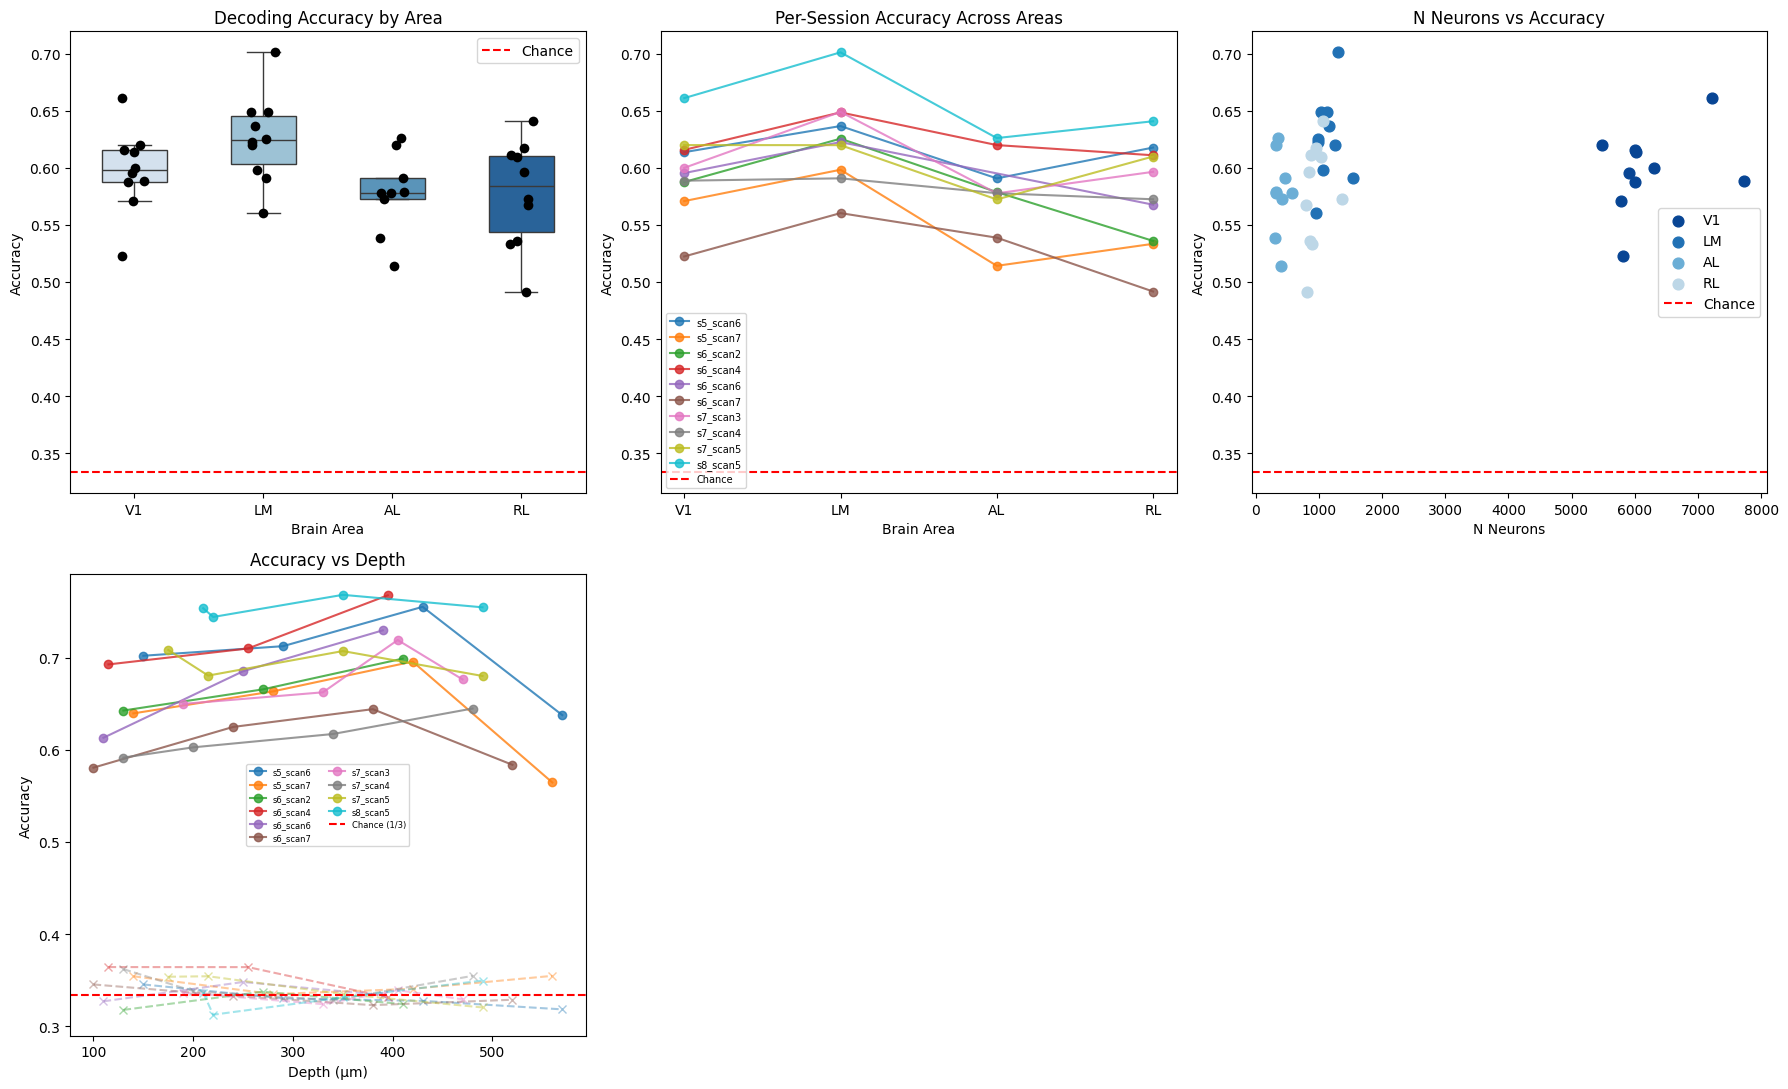

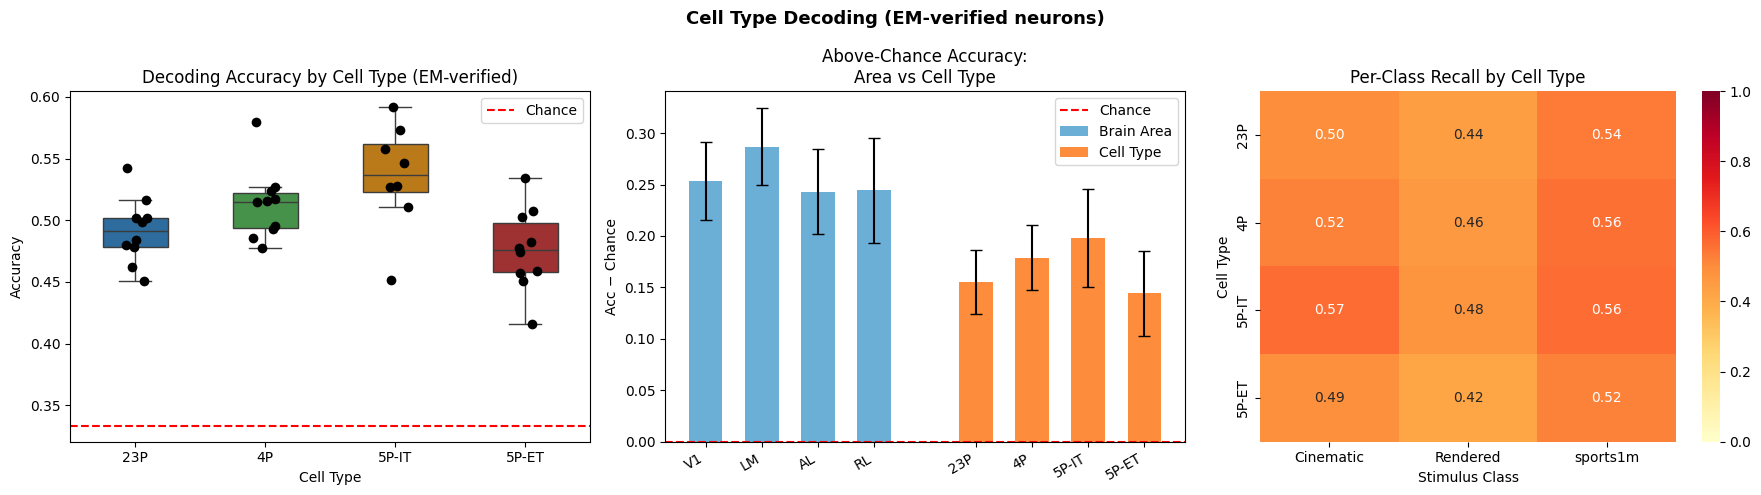

In [59]:
# CELL 5 — ANALYSIS (Area + Depth + Cell Type)
df = pd.concat([pd.read_csv(f) for f in glob.glob(f"{RESULTS_DIR}/results_s*.csv")], ignore_index=True)
df['session_label'] = 's' + df['session'].astype(str) + '_scan' + df['scan'].astype(str)
df['AboveChance'] = df['Acc'] - df['Chance']
print(f"Loaded {df.groupby(['session','scan']).ngroups} session-scans | {len(df)} rows")

AREA_ORDER = ['V1', 'LM', 'AL', 'RL']
CT_ORDER   = ['23P', '4P', '5P-IT', '5P-ET']
CLASSES    = ['Cinematic', 'Rendered', 'sports1m']

area_df = df[df['Type'] == 'Area'].copy()
area_df['brain_area'] = pd.Categorical(area_df['brain_area'], categories=AREA_ORDER, ordered=True)

ct_df = df[df['Type'] == 'CellType'].copy()
ct_df['cell_type'] = pd.Categorical(ct_df['cell_type'], categories=CT_ORDER, ordered=True)

# ── Figure 1: Area plots (unchanged) ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

ax = axes[0,0]
sns.boxplot(data=area_df, x='brain_area', y='Acc', order=AREA_ORDER,
            palette='Blues', ax=ax, width=0.5, fliersize=0)
sns.stripplot(data=area_df, x='brain_area', y='Acc', order=AREA_ORDER,
              color='black', size=7, jitter=True, ax=ax, zorder=5)
ax.axhline(1/3, color='red', linestyle='--', label='Chance')
ax.set_title('Decoding Accuracy by Area'); ax.set_xlabel('Brain Area'); ax.set_ylabel('Accuracy')
ax.legend()

ax = axes[0,1]
for sess in area_df['session_label'].unique():
    sub = area_df[area_df['session_label'] == sess].sort_values('brain_area')
    ax.plot(sub['brain_area'].astype(str), sub['Acc'], marker='o', label=sess, alpha=0.8)
ax.axhline(1/3, color='red', linestyle='--', label='Chance')
ax.set_title('Per-Session Accuracy Across Areas')
ax.set_xlabel('Brain Area'); ax.set_ylabel('Accuracy')
ax.legend(fontsize=7)

ax = axes[0,2]
colors = {'V1':'#084594','LM':'#2171b5','AL':'#6baed6','RL':'#bdd7e7'}
for area in AREA_ORDER:
    sub = area_df[area_df['brain_area']==area]
    ax.scatter(sub['N_neurons'], sub['Acc'], label=area,
               color=colors[area], s=60, zorder=5)
ax.axhline(1/3, color='red', linestyle='--', label='Chance')
ax.set_title('N Neurons vs Accuracy'); ax.set_xlabel('N Neurons'); ax.set_ylabel('Accuracy')
ax.legend()

ax = axes[1,0]
depth_df = df[df['Type'] == 'Depth'].copy()
depth_df['depth_val'] = depth_df['Group'].str.replace('um','').astype(float)
depth_df_sorted = depth_df.sort_values('depth_val')
session_palette = plt.cm.tab10.colors
sessions = depth_df['session_label'].unique()
sess_color = {s: session_palette[i % 10] for i, s in enumerate(sessions)}
for sess in sessions:
    sub = depth_df_sorted[depth_df_sorted['session_label'] == sess]
    c = sess_color[sess]
    ax.plot(sub['depth_val'], sub['Acc'], marker='o', color=c, label=sess, alpha=0.8)
    ax.plot(sub['depth_val'], sub['Chance'], marker='x', color=c, linestyle='--', alpha=0.4)
ax.axhline(1/3, color='red', linestyle='--', label='Chance (1/3)')
ax.set_title('Accuracy vs Depth'); ax.set_xlabel('Depth (µm)'); ax.set_ylabel('Accuracy')
ax.legend(fontsize=6, ncol=2)

axes[1,1].set_visible(False)
axes[1,2].set_visible(False)

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/analysis_plots.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Cell Type plots ─────────────────────────────────────────────────
if len(ct_df) == 0:
    print("No cell type results yet — run sessions first.")
else:
    ct_palette = {'23P':'#1a6faf','4P':'#3a9f3f','5P-IT':'#d47f00','5P-ET':'#b02020'}

    fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

    # Plot A: Boxplot by cell type
    ax = axes2[0]
    sns.boxplot(data=ct_df, x='cell_type', y='Acc', order=CT_ORDER,
                palette=ct_palette, ax=ax, width=0.5, fliersize=0)
    sns.stripplot(data=ct_df, x='cell_type', y='Acc', order=CT_ORDER,
                  color='black', size=7, jitter=True, ax=ax, zorder=5)
    ax.axhline(1/3, color='red', linestyle='--', label='Chance')
    ax.set_title('Decoding Accuracy by Cell Type (EM-verified)')
    ax.set_xlabel('Cell Type'); ax.set_ylabel('Accuracy')
    ax.legend()

    # Plot B: Cell type vs Area — above-chance comparison side by side
    ax = axes2[1]
    # Mean above-chance per group, with error bars (std across sessions)
    area_summary = area_df.groupby('brain_area')['AboveChance'].agg(['mean','std']).reindex(AREA_ORDER)
    ct_summary   = ct_df.groupby('cell_type')['AboveChance'].agg(['mean','std']).reindex(CT_ORDER)
    x_area = np.arange(len(AREA_ORDER))
    x_ct   = np.arange(len(CT_ORDER)) + len(AREA_ORDER) + 0.8
    ax.bar(x_area, area_summary['mean'], yerr=area_summary['std'],
           color='#6baed6', label='Brain Area', capsize=4, width=0.6)
    ax.bar(x_ct,   ct_summary['mean'],   yerr=ct_summary['std'],
           color='#fd8d3c', label='Cell Type', capsize=4, width=0.6)
    ax.axhline(0, color='red', linestyle='--', label='Chance')
    ax.set_xticks(np.concatenate([x_area, x_ct]))
    ax.set_xticklabels(AREA_ORDER + CT_ORDER, rotation=30, ha='right')
    ax.set_title('Above-Chance Accuracy:\nArea vs Cell Type'); ax.set_ylabel('Acc − Chance')
    ax.legend()

    # Plot C: Per-class recall by cell type (heatmap)
    ax = axes2[2]
    recall_cols = ['recall_Cinematic', 'recall_Rendered', 'recall_sports1m']
    recall_mean = ct_df.groupby('cell_type')[recall_cols].mean().reindex(CT_ORDER)
    recall_mean.columns = ['Cinematic', 'Rendered', 'sports1m']
    sns.heatmap(recall_mean, annot=True, fmt='.2f', cmap='YlOrRd',
                vmin=0, vmax=1, ax=ax)
    ax.set_title('Per-Class Recall by Cell Type')
    ax.set_xlabel('Stimulus Class'); ax.set_ylabel('Cell Type')

    fig2.suptitle('Cell Type Decoding (EM-verified neurons)', fontsize=13, fontweight='bold')
    fig2.tight_layout()
    fig2.savefig(f"{RESULTS_DIR}/analysis_celltype.png", dpi=150, bbox_inches='tight')
    plt.show()


  Aligned: (9941, 40000) | Trials: 384
Running N-curve for s8_scan5...
  23P (N=892)
    N=20   Acc=0.497±0.032
    N=40   Acc=0.537±0.026
    N=80   Acc=0.536±0.014
    N=150  Acc=0.592±0.048
    N=200  Acc=0.612±0.018
  4P (N=460)
    N=20   Acc=0.539±0.025
    N=40   Acc=0.563±0.038
    N=80   Acc=0.560±0.039
    N=150  Acc=0.629±0.017
    N=200  Acc=0.656±0.010
  5P-IT (N=106)
    N=20   Acc=0.529±0.036
    N=40   Acc=0.579±0.019
    N=80   Acc=0.587±0.033
  5P-ET (N=91)
    N=20   Acc=0.538±0.023
    N=40   Acc=0.575±0.012
    N=80   Acc=0.593±0.012


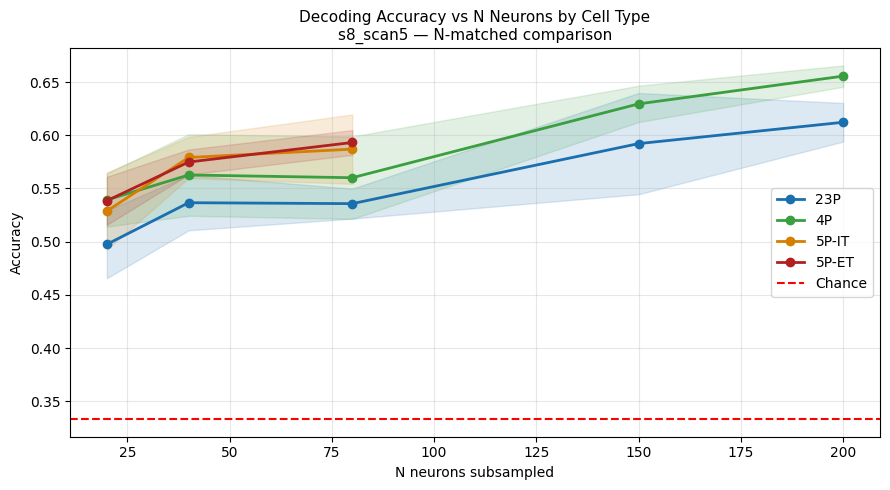

In [61]:
# CELL 6 N-CURVE ANALYSIS
# Re-runs decoder at increasing N for each cell type to verify that accuracy
# differences are not just a sample-size artifact.

activity, frame_times, trials, merged = load_and_align_data(NWB_PATH, METADATA_PATH, SESSION, SCAN)
X, y = extract_features(activity, frame_times, trials)

del activity
N_CURVE_STEPS    = [20, 40, 80,150, 200]
N_CURVE_BOOTS    = 3
CT_PALETTE       = {'23P':'#1a6faf','4P':'#3a9f3f','5P-IT':'#d47f00','5P-ET':'#b02020'}

print(f"Running N-curve for s{SESSION}_scan{SCAN}...")
ct_col    = merged['cell_type'].astype(str).values
ncurve_rows = []

for ct in MAIN_CELL_TYPES:
    mask = np.asarray(ct_col == ct, dtype=bool)
    n_avail = mask.sum()
    if n_avail < N_CURVE_STEPS[0]:
        print(f"  SKIP {ct} — only {n_avail} neurons"); continue
    print(f"  {ct} (N={n_avail})")
    for n in N_CURVE_STEPS:
        if n > n_avail:
            break
        acc, std, chance, _, _, _ = run_decoder(X[:, mask], y, n, N_CURVE_BOOTS)
        ncurve_rows.append({'cell_type': ct, 'N': n, 'Acc': acc, 'Std': std, 'Chance': chance})
        print(f"    N={n:<4} Acc={acc:.3f}±{std:.3f}")

ncurve_df = pd.DataFrame(ncurve_rows)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for ct in MAIN_CELL_TYPES:
    sub = ncurve_df[ncurve_df['cell_type'] == ct]
    if sub.empty: continue
    color = CT_PALETTE[ct]
    ax.plot(sub['N'], sub['Acc'], marker='o', color=color, label=ct, linewidth=2)
    ax.fill_between(sub['N'],
                    sub['Acc'] - sub['Std'],
                    sub['Acc'] + sub['Std'],
                    color=color, alpha=0.15)

ax.axhline(1/3, color='red', linestyle='--', label='Chance')
ax.set_title(f'Decoding Accuracy vs N Neurons by Cell Type\n'
             f's{SESSION}_scan{SCAN} — N-matched comparison',
             fontsize=11)
ax.set_xlabel('N neurons subsampled'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/ncurve_s{SESSION}_scan{SCAN}.png", dpi=150, bbox_inches='tight')
plt.show()

In [17]:
meta = pd.read_pickle(METADATA_PATH)

# Overall cell type coverage
print("Cell type counts (all sessions)")
print(meta['cell_type'].value_counts())
print(f"\nTotal units: {len(meta)}")
print(f"Units with cell_type: {meta['cell_type'].notna().sum()} ({meta['cell_type'].notna().mean()*100:.1f}%)")

# Per session coverage
print("\nPer session: min neurons per cell type")
for (sess, scan), grp in meta.groupby(['session', 'scan_idx']):
    ct_counts = grp['cell_type'].value_counts()
    print(f"s{sess}_scan{scan}: {dict(ct_counts)} | min={ct_counts.min()}, n_types={len(ct_counts)}")

=== Cell type counts (all sessions) ===
cell_type
23P          9023
4P           5888
5P-IT        2318
5P-ET         955
6P-IT         474
6P-CT         220
BC            175
MC            158
NGC           137
pericyte      115
5P-NP          69
astrocyte      37
BPC            26
OPC            17
microglia      15
oligo          12
Name: count, dtype: Int64

Total units: 156239
Units with cell_type: 19639 (12.6%)

=== Per session: min neurons per cell type ===
s4_scan7: {'23P': np.int64(630), '4P': np.int64(417), '5P-ET': np.int64(110), '5P-IT': np.int64(83), 'MC': np.int64(14), '5P-NP': np.int64(6), 'astrocyte': np.int64(2), 'NGC': np.int64(1), 'BPC': np.int64(1), 'OPC': np.int64(1), '6P-CT': np.int64(1)} | min=1, n_types=11
s4_scan9: {} | min=<NA>, n_types=0
s4_scan10: {} | min=<NA>, n_types=0
s5_scan3: {'23P': np.int64(126), '5P-ET': np.int64(101), '4P': np.int64(70), '5P-IT': np.int64(65), '6P-IT': np.int64(24), '6P-CT': np.int64(17), 'MC': np.int64(9), '5P-NP': np.int64(1)} | 